# W1 数据清洗与特征工程

预测背景与输入变量（Abstract & Introduction）

- **GEFCom2014**：全球能源预测竞赛 2014，目标为电力负荷预测。
- **预测任务**：用历史负荷及辅助变量预测下一时刻负荷 $Y_{t+1}$。
- **Input Variables**（文中常用设定）：
  - **LOAD**：历史负荷（主要信号）；
  - **w1–w25**：辅助变量（如温度、湿度等气象或日历编码）。
- 本实验使用 **L1-train** 数据：含 ZONEID、TIMESTAMP、LOAD、w1–w25。要求用 $X_{t-d}, \ldots, X_t$ 构造 Lag 特征预测 $Y_{t+1}$。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 数据准备：读取 GEFCom2014 L1-train 负荷数据
df = pd.read_csv('../data/GEFCom2014/L1-train.csv')
df

,ZONEID,TIMESTAMP,LOAD,w1,w2,w3,w4,w5,w6,w7,...,w16,w17,w18,w19,w20,w21,w22,w23,w24,w25
0,1,112001 1:00,NaN,27,28,18,23,25,27,26,...,25,23,25,27,27,29,30,25,26,27
1,1,112001 2:00,NaN,25,28,18,23,24,24,26,...,25,23,25,27,23,28,30,24,22,27
2,1,112001 3:00,NaN,27,23,18,24,23,24,23,...,26,24,21,27,25,29,28,24,23,25
3,1,112001 4:00,NaN,25,21,19,24,23,24,22,...,25,24,21,27,23,27,28,23,26,25
4,1,112001 5:00,NaN,27,21,19,22,23,24,22,...,27,22,21,27,25,27,28,23,25,27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85435,1,9302010 20:00,176.8,75,70,61,73,72,79,70,...,70,72,73,71,70,77,70,71,71,71
85436,1,9302010 21:00,169.4,75,70,61,72,72,79,69,...,70,70,72,70,70,77,70,72,70,70
85437,1,9302010 22:00,155.8,74,70,61,71,71,70,70,...,70,70,70,70,70,72,70,71,70,70
85438,1,9302010 23:00,143.8,73,70,61,69,71,70,70,...,69,69,72,69,70,69,68,72,72,70


## 1. TIMESTAMP 解析

TIMESTAMP 格式说明：
- 格式：`MMDDYYYY HH:MM`（如 `1112001` = 2001年11月1日 或 2001年1月11日）
- 负荷数据：69个月（2005年1月至2010年9月）
- 天气数据：117个月（2001年1月到2010年9月）
- 解析为 datetime 并提取时间特征

In [ ]:
from datetime import datetime

# 用来保存解析后的结果
years, months, days, datetimes = [], [], [], []

# 记录当前月份的字符串（初始化为 None，第一行时再推断）
month_str = None

# 注意 iterrows 返回 (idx, row)
for _, row in df.iterrows():
    time_str_full = row['TIMESTAMP']
    # 拆分日期和时间
    date_str, hm_str = time_str_full.split(' ')
    # 年份：后四位
    year = int(date_str[-4:])
    # 月+日的部分（前几位）
    month_day_str = date_str[:-4]

    # 第一行：根据当前串先猜一个月份字符串（去掉最后一位做成“月”的部分）
    if month_str is None:
        month_str = month_day_str[:-1]

    # 按当前的 month_str 长度截取“当前看到的月份”
    if len(month_str) == 1:
        current_month = month_day_str[0]
    elif len(month_str) == 2:
        current_month = month_day_str[:2]

    # 如果月份更新了，说明这一行是新月份的第 1 天：日肯定只有一位, 前面的数字肯定是月份
    if current_month != month_str:
        month_str = month_day_str[:-1]

    # 按现在的 month_str 长度截取“日”
    if len(month_str) == 1:
        day = int(month_day_str[1:])
    elif len(month_str) == 2:
        day = int(month_day_str[2:])

    month = int(month_str)

    # 解析小时和分钟
    hour, minute = map(int, hm_str.split(':'))
    dt = datetime(year, month, day, hour, minute)

    # 收集结果
    datetimes.append(dt)

# 写回到 df
df.drop(columns=['TIMESTAMP'], inplace=True)
df['datetime'] = pd.to_datetime(datetimes)
df

,ZONEID,LOAD,w1,w2,w3,w4,w5,w6,w7,w8,...,w17,w18,w19,w20,w21,w22,w23,w24,w25,datetime
0,1,NaN,27,28,18,23,25,27,26,26,...,23,25,27,27,29,30,25,26,27,2001-01-01 01:00:00
1,1,NaN,25,28,18,23,24,24,26,24,...,23,25,27,23,28,30,24,22,27,2001-01-01 02:00:00
2,1,NaN,27,23,18,24,23,24,23,23,...,24,21,27,25,29,28,24,23,25,2001-01-01 03:00:00
3,1,NaN,25,21,19,24,23,24,22,23,...,24,21,27,23,27,28,23,26,25,2001-01-01 04:00:00
4,1,NaN,27,21,19,22,23,24,22,22,...,22,21,27,25,27,28,23,25,27,2001-01-01 05:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85435,1,176.8,75,70,61,73,72,79,70,71,...,72,73,71,70,77,70,71,71,71,2010-09-30 20:00:00
85436,1,169.4,75,70,61,72,72,79,69,70,...,70,72,70,70,77,70,72,70,70,2010-09-30 21:00:00
85437,1,155.8,74,70,61,71,71,70,70,70,...,70,70,70,70,72,70,71,70,70,2010-09-30 22:00:00
85438,1,143.8,73,70,61,69,71,70,70,70,...,69,72,69,70,69,68,72,72,70,2010-09-30 23:00:00


In [4]:
# 数据基本信息与缺失情况
df.info()
print('\nLOAD 缺失数量:', df['LOAD'].isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85440 entries, 0 to 85439
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   ZONEID    85440 non-null  int64         
 1   LOAD      50376 non-null  float64       
 2   w1        85440 non-null  int64         
 3   w2        85440 non-null  int64         
 4   w3        85440 non-null  int64         
 5   w4        85440 non-null  int64         
 6   w5        85440 non-null  int64         
 7   w6        85440 non-null  int64         
 8   w7        85440 non-null  int64         
 9   w8        85440 non-null  int64         
 10  w9        85440 non-null  int64         
 11  w10       85440 non-null  int64         
 12  w11       85440 non-null  int64         
 13  w12       85440 non-null  int64         
 14  w13       85440 non-null  int64         
 15  w14       85440 non-null  int64         
 16  w15       85440 non-null  int64         
 17  w16       85

In [5]:
# 前几行预览
df.head(10)

,ZONEID,LOAD,w1,w2,w3,w4,w5,w6,w7,w8,...,w17,w18,w19,w20,w21,w22,w23,w24,w25,datetime
0,1,NaN,27,28,18,23,25,27,26,26,...,23,25,27,27,29,30,25,26,27,2001-01-01 01:00:00
1,1,NaN,25,28,18,23,24,24,26,24,...,23,25,27,23,28,30,24,22,27,2001-01-01 02:00:00
2,1,NaN,27,23,18,24,23,24,23,23,...,24,21,27,25,29,28,24,23,25,2001-01-01 03:00:00
3,1,NaN,25,21,19,24,23,24,22,23,...,24,21,27,23,27,28,23,26,25,2001-01-01 04:00:00
4,1,NaN,27,21,19,22,23,24,22,22,...,22,21,27,25,27,28,23,25,27,2001-01-01 05:00:00
5,1,NaN,28,25,18,22,23,25,24,22,...,22,25,27,25,26,27,22,25,27,2001-01-01 06:00:00
6,1,NaN,21,25,20,22,21,26,25,21,...,22,25,27,25,27,27,22,25,25,2001-01-01 07:00:00
7,1,NaN,20,23,19,21,20,27,26,21,...,21,25,28,28,27,27,22,22,25,2001-01-01 08:00:00
8,1,NaN,30,28,21,26,20,29,29,21,...,26,27,28,30,28,30,21,28,28,2001-01-01 09:00:00
9,1,NaN,34,32,22,30,27,30,32,26,...,30,32,32,34,31,32,26,31,32,2001-01-01 10:00:00


In [6]:
# 数值列描述统计
df.describe()

,ZONEID,LOAD,w1,w2,w3,w4,w5,w6,w7,w8,...,w17,w18,w19,w20,w21,w22,w23,w24,w25,datetime
count,85440.0,50376.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,...,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440.000000,85440
mean,1.0,145.641196,61.380723,61.320435,55.731039,61.079670,63.163729,61.375199,62.394534,63.018961,...,60.342381,63.591081,58.809995,62.787839,61.038249,62.751381,62.557128,61.026627,60.430630,2005-11-16 00:30:00
min,1.0,48.400000,9.000000,9.000000,4.000000,10.000000,14.000000,12.000000,11.000000,12.000000,...,9.000000,10.000000,7.000000,12.000000,15.000000,9.000000,10.000000,11.000000,9.000000,2001-01-01 01:00:00
25%,1.0,110.200000,48.000000,48.000000,43.000000,48.750000,51.000000,48.000000,50.000000,50.000000,...,47.000000,52.000000,46.000000,51.000000,48.000000,50.000000,49.000000,48.000000,47.000000,2003-06-10 00:45:00
50%,1.0,134.900000,63.000000,64.000000,58.000000,63.000000,65.000000,63.000000,65.000000,65.000000,...,63.000000,66.000000,61.000000,66.000000,63.000000,64.000000,64.000000,63.000000,63.000000,2005-11-16 00:30:00
75%,1.0,173.600000,75.000000,73.000000,68.000000,74.000000,75.000000,75.000000,75.000000,76.000000,...,73.000000,76.000000,72.000000,75.000000,74.000000,75.000000,76.000000,74.000000,73.000000,2008-04-24 00:15:00
max,1.0,315.600000,104.000000,104.000000,93.000000,103.000000,103.000000,100.000000,100.000000,104.000000,...,102.000000,100.000000,100.000000,99.000000,104.000000,102.000000,104.000000,104.000000,104.000000,2010-10-01 00:00:00
std,0.0,46.659266,17.349542,16.988374,16.240793,16.486492,16.337378,16.249974,16.001921,16.600910,...,16.846127,14.895249,16.602281,15.823021,16.340907,16.761918,17.399563,17.121820,17.093968,NaN


## 2. 数据清洗

- 处理缺失值：删除 LOAD 为空的行（或仅保留有标签的时段）。
- 归一化：对 LOAD 及数值型辅助变量做 Min-Max 归一化到 [0, 1]。

In [7]:
# 删除 LOAD 缺失行
df_clean = df.dropna(subset=['LOAD']).copy()
# 数值列（用于归一化）：LOAD + w1..w25
num_cols = ['LOAD'] + [c for c in df_clean.columns if c.startswith('w') and c[1:].isdigit()]
# Min-Max 归一化
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
print('清洗后样本数:', len(df_clean))
df_clean.head()

清洗后样本数: 50376


,ZONEID,LOAD,w1,w2,w3,w4,w5,w6,w7,w8,...,w17,w18,w19,w20,w21,w22,w23,w24,w25,datetime
35064,1,0.289671,0.357895,0.389474,0.404494,0.391304,0.364706,0.364706,0.341176,0.434783,...,0.322581,0.417722,0.408602,0.436782,0.352273,0.344086,0.393617,0.387097,0.378947,2005-01-01 01:00:00
35065,1,0.274701,0.336842,0.389474,0.382022,0.380435,0.364706,0.352941,0.423529,0.413043,...,0.344086,0.405063,0.419355,0.402299,0.352273,0.387097,0.393617,0.387097,0.378947,2005-01-01 02:00:00
35066,1,0.256737,0.326316,0.389474,0.370787,0.369565,0.329412,0.352941,0.400000,0.391304,...,0.365591,0.417722,0.408602,0.379310,0.340909,0.387097,0.382979,0.376344,0.357895,2005-01-01 03:00:00
35067,1,0.247006,0.315789,0.389474,0.370787,0.391304,0.364706,0.388235,0.352941,0.413043,...,0.365591,0.405063,0.387097,0.379310,0.318182,0.387097,0.393617,0.387097,0.368421,2005-01-01 04:00:00
35068,1,0.244012,0.305263,0.389474,0.370787,0.358696,0.364706,0.400000,0.329412,0.413043,...,0.365591,0.405063,0.387097,0.356322,0.329545,0.387097,0.393617,0.376344,0.368421,2005-01-01 05:00:00


## 3. 构造滑窗数据集（Lag features）

编写函数：用 $X_{t-d}, \ldots, X_t$ 预测 $Y_{t+1}$。即每个样本的输入为过去 `d+1` 个时间步的特征（含当前时刻），目标为下一时刻的 LOAD。

In [8]:
def build_lag_dataset(series, d, target_col='LOAD'):
    """
    构建滑窗数据集：用 X_{t-d}, ..., X_t 预测 Y_{t+1}。
    series: DataFrame，按时间序排列，含 target_col 及可选辅助列
    d: 滞后阶数，共 d+1 个时间步作为输入
    返回: X (n_samples, d+1, n_features), y (n_samples,)
    """
    if target_col not in series.columns:
        raise ValueError(f'缺少列 {target_col}')
    # 使用所有数值列作为特征（或仅 LOAD）
    use_cols = [target_col] + [c for c in series.columns if c.startswith('w') and c[1:].isdigit()]
    mat = series[use_cols].values  # (T, n_features)
    n_features = mat.shape[1]
    T = len(mat)
    if T <= d + 1:
        return np.empty((0, d + 1, n_features)), np.empty(0)
    X_list, y_list = [], []
    for t in range(d, T - 1):
        # 输入: [t-d, t-d+1, ..., t] 共 d+1 步，保持二维形状 (d+1, n_features)
        x = mat[t - d : t + 1]  # (d+1, n_features)
        y = mat[t + 1, 0]  # 下一时刻 LOAD（假设 LOAD 在 use_cols 第 0 列）
        X_list.append(x)
        y_list.append(y)
    return np.array(X_list), np.array(y_list)

In [9]:
# 取滞后阶数 d（例如 d=23 表示用过去 24 个时间步预测下一步）
d = 24 - 1
X, y = build_lag_dataset(df_clean, d=d)
# 展示特征矩阵与目标的维度 (Shape)
print('特征矩阵 X 维度 (Shape):', X.shape)
print('目标 y 维度 (Shape):', y.shape)
print('即: 用过去', d + 1, '个时间步的 LOAD+w1..w25（共 26 维）预测下一时刻 LOAD；每样本特征形状 = (', d+1, ', 26)')

特征矩阵 X 维度 (Shape): (50352, 24, 26)
目标 y 维度 (Shape): (50352,)
即: 用过去 24 个时间步的 LOAD+w1..w25（共 26 维）预测下一时刻 LOAD；每样本特征形状 = ( 24 , 26)


In [10]:
# 数据准备：获取有负荷的数据
import numpy as np
from scipy import stats

df_load = df_clean[df_clean['LOAD'].notna()].copy()
load_values = df_load['LOAD'].values

print(f'负荷数据总数: {len(load_values)}')
print(f'负荷范围: [{load_values.min():.4f}, {load_values.max():.4f}]')
print(f'均值: {load_values.mean():.4f}, 标准差: {load_values.std():.4f}')

负荷数据总数: 50376
负荷范围: [0.0000, 1.0000]
均值: 0.3639, 标准差: 0.1746


## 4. 负荷曲线展示

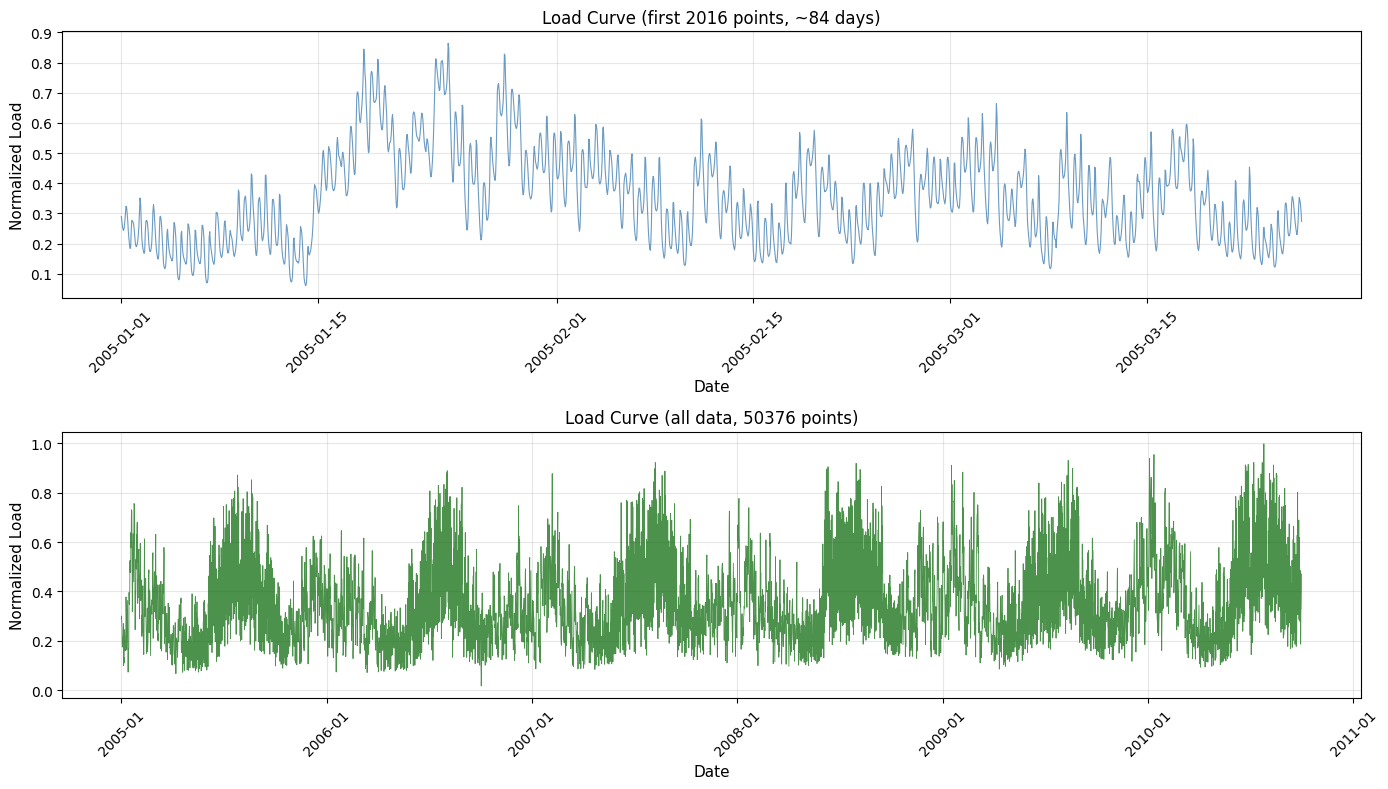


负荷数据统计:
  总时间点: 50376
  有负荷数据的时间点: 50376
  时间范围: 2005-01-01 01:00:00 至 2010-10-01 00:00:00
  负荷范围: [0.0000, 1.0000] (归一化后)


In [11]:
# 日期顺序展示负荷曲线
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 确保按日期排序
df_plot = df_clean.sort_values('datetime').copy()

# 创建图形
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# 上图：显示前 2016 个点（约 84 天）的负荷曲线
n_show = min(2016, len(df_plot))
axes[0].plot(df_plot['datetime'].iloc[:n_show], df_plot['LOAD'].iloc[:n_show], 
              linewidth=0.8, alpha=0.8, color='steelblue')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('Normalized Load', fontsize=11)
axes[0].set_title(f'Load Curve (first {n_show} points, ~{n_show//24} days)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[0].tick_params(axis='x', rotation=45)

# 下图：显示所有有负荷数据的曲线（采样显示，避免过于密集）
df_load = df_plot[df_plot['LOAD'].notna()]
if len(df_load) > 5000:
    # 如果数据太多，采样显示
    step = len(df_load) // 5000
    df_load_sample = df_load.iloc[::step]
else:
    df_load_sample = df_load

axes[1].plot(df_load_sample['datetime'], df_load_sample['LOAD'], 
              linewidth=0.6, alpha=0.7, color='darkgreen')
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_ylabel('Normalized Load', fontsize=11)
axes[1].set_title(f'Load Curve (all data, {len(df_load)} points)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 打印统计信息
print(f'\n负荷数据统计:')
print(f'  总时间点: {len(df_plot)}')
print(f'  有负荷数据的时间点: {len(df_load)}')
print(f'  时间范围: {df_load["datetime"].min()} 至 {df_load["datetime"].max()}')
print(f'  负荷范围: [{df_load["LOAD"].min():.4f}, {df_load["LOAD"].max():.4f}] (归一化后)')

## 5. 异常值检测 (补充,并未采用)

In [12]:
# 3-sigma原则检测异常值
mean_load = np.mean(load_values)
std_load = np.std(load_values)
lower_bound_3sigma = mean_load - 3 * std_load
upper_bound_3sigma = mean_load + 3 * std_load
outliers_3sigma = (load_values < lower_bound_3sigma) | (load_values > upper_bound_3sigma)

print(f'3-sigma方法检测结果:')
print(f'  均值: {mean_load:.4f}, 标准差: {std_load:.4f}')
print(f'  下界: {lower_bound_3sigma:.4f}, 上界: {upper_bound_3sigma:.4f}')
print(f'  检测到异常值: {outliers_3sigma.sum()} 个 ({outliers_3sigma.sum()/len(load_values)*100:.2f}%)')

3-sigma方法检测结果:
  均值: 0.3639, 标准差: 0.1746
  下界: -0.1599, 上界: 0.8878
  检测到异常值: 176 个 (0.35%)


In [13]:
# IQR方法检测异常值
Q1 = np.percentile(load_values, 25)
Q3 = np.percentile(load_values, 75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR
outliers_iqr = (load_values < lower_bound_iqr) | (load_values > upper_bound_iqr)

print(f'IQR方法检测结果:')
print(f'  Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}')
print(f'  下界: {lower_bound_iqr:.4f}, 上界: {upper_bound_iqr:.4f}')
print(f'  检测到异常值: {outliers_iqr.sum()} 个 ({outliers_iqr.sum()/len(load_values)*100:.2f}%)')

IQR方法检测结果:
  Q1: 0.2313, Q3: 0.4686, IQR: 0.2373
  下界: -0.1246, 上界: 0.8245
  检测到异常值: 599 个 (1.19%)


In [14]:
# Z-score方法检测异常值（阈值=3）
z_scores = np.abs(stats.zscore(load_values))
outliers_zscore = z_scores > 3

print(f'Z-score方法检测结果:')
print(f'  Z-score范围: [{z_scores.min():.4f}, {z_scores.max():.4f}]')
print(f'  阈值: ±3')
print(f'  检测到异常值: {outliers_zscore.sum()} 个 ({outliers_zscore.sum()/len(load_values)*100:.2f}%)')

Z-score方法检测结果:
  Z-score范围: [0.0009, 3.6426]
  阈值: ±3
  检测到异常值: 176 个 (0.35%)
